In [1]:
import pandas as pd


In [5]:
data = pd.read_csv(r"C:\Users\abdo\Downloads\Uber\uber.csv")

In [6]:
data.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 23.4 MB


In [9]:
data.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [10]:
data = data.dropna()

In [11]:
data.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [12]:
data.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='str')

In [20]:

data.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')


data.columns

Index(['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='str')

In [22]:
# تحويل عمود التاريخ والوقت
data['pickup_datetime'] = pd.to_datetime(
    data['pickup_datetime'],
    errors='coerce',
    utc=True
)

# فحص نوع كل عمود وعدد القيم غير الفارغة
data.info()


data.isnull().sum()

<class 'pandas.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                199999 non-null  str                
 1   fare_amount        199999 non-null  float64            
 2   pickup_datetime    199999 non-null  datetime64[us, UTC]
 3   pickup_longitude   199999 non-null  float64            
 4   pickup_latitude    199999 non-null  float64            
 5   dropoff_longitude  199999 non-null  float64            
 6   dropoff_latitude   199999 non-null  float64            
 7   passenger_count    199999 non-null  int64              
dtypes: datetime64[us, UTC](1), float64(5), int64(1), str(1)
memory usage: 19.0 MB


key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [23]:
data.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
1,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
2,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
3,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5


Deletmoutliers

In [28]:
data.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,11.359892,-72.527631,39.935881,-72.525292,39.923890,1.684543
std,9.901760,11.437815,7.720558,13.117408,6.794829,1.385995
min,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [30]:

data = data.dropna()

data = data[
    (data['fare_amount'] > 0) &
    (data['passenger_count'].between(1, 6)) &
    (data['pickup_latitude'].between(40.4, 41.0)) &
    (data['dropoff_latitude'].between(40.4, 41.0)) &
    (data['pickup_longitude'].between(-74.3, -73.6)) &
    (data['dropoff_longitude'].between(-74.3, -73.6))
]

print(data.shape)

(194923, 8)


In [31]:

Q1 = data['fare_amount'].quantile(0.25)
Q3 = data['fare_amount'].quantile(0.75)

IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

data = data[
    (data['fare_amount'] >= lower_limit) &
    (data['fare_amount'] <= upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Final shape:", data.shape)

Lower limit: -3.75
Upper limit: 22.25
Final shape: (178274, 8)


In [32]:

data[['fare_amount', 'pickup_longitude', 'pickup_latitude',
      'dropoff_longitude', 'dropoff_latitude',
      'passenger_count']].describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,178274.000000,178274.000000,178274.000000,178274.000000,178274.000000,178274.000000
mean,8.943538,-73.980006,40.751981,-73.978280,40.752234,1.686909
std,4.138532,0.022344,0.024036,0.023499,0.026551,1.304190
min,0.010000,-74.299012,40.400072,-74.299833,40.400050,1.000000
25%,5.700000,-73.992598,40.737132,-73.991862,40.736897,1.000000
50%,8.000000,-73.982520,40.753196,-73.981247,40.753842,1.000000
75%,11.000000,-73.970318,40.766850,-73.968005,40.767782,2.000000
max,22.200000,-73.622390,40.983720,-73.628092,40.996788,6.000000


In [34]:

data['pickup_hour'] = data['pickup_datetime'].dt.hour
data['pickup_day'] = data['pickup_datetime'].dt.day_name()
data['pickup_month'] = data['pickup_datetime'].dt.month
data['pickup_year'] = data['pickup_datetime'].dt.year

data[['pickup_datetime', 'pickup_hour', 'pickup_day',
      'pickup_month', 'pickup_year']].head()

,pickup_datetime,pickup_hour,pickup_day,pickup_month,pickup_year
0,2015-05-07 19:52:06+00:00,19,Thursday,5,2015
1,2009-07-17 20:04:56+00:00,20,Friday,7,2009
2,2009-08-24 21:45:00+00:00,21,Monday,8,2009
3,2009-06-26 08:22:21+00:00,8,Friday,6,2009
4,2014-08-28 17:47:00+00:00,17,Thursday,8,2014


In [35]:

hourly_fare = data.groupby('pickup_hour')['fare_amount'].mean()

hourly_fare

pickup_hour
0     9.465071
1     9.559259
2     9.432533
3     9.599655
4     9.889572
5     8.813794
6     8.213268
7     8.569758
8     8.841918
9     8.857684
10    8.761907
11    8.797229
12    8.900172
13    8.772179
14    8.848494
15    8.808127
16    8.551893
17    8.840987
18    8.919137
19    8.867251
20    8.872280
21    9.003878
22    9.226281
23    9.280655
Name: fare_amount, dtype: float64

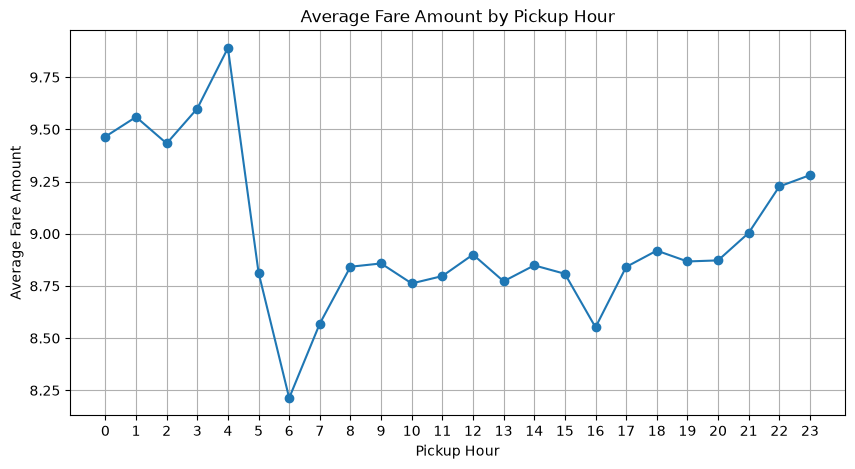

In [36]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(hourly_fare.index, hourly_fare.values, marker='o')
plt.title('Average Fare Amount by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Fare Amount')
plt.xticks(range(24))
plt.grid()
plt.show()

Transform coordinate points

In [37]:
import numpy as np


def haversine_distance(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return earth_radius_km * c



data['distance_km'] = haversine_distance(
    data['pickup_latitude'],
    data['pickup_longitude'],
    data['dropoff_latitude'],
    data['dropoff_longitude']
)


data[['pickup_latitude', 'pickup_longitude',
      'dropoff_latitude', 'dropoff_longitude',
      'distance_km']].head()

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,distance_km
0,40.738354,-73.999817,40.723217,-73.999512,1.683323
1,40.728225,-73.994355,40.750325,-73.994710,2.457590
2,40.740770,-74.005043,40.772647,-73.962565,5.036377
3,40.790844,-73.976124,40.803349,-73.965316,1.661683
4,40.744085,-73.925023,40.761247,-73.973082,4.475450


In [38]:

data.drop(
    columns=[
        'key',
        'pickup_longitude',
        'pickup_latitude',
        'dropoff_longitude',
        'dropoff_latitude'
    ],
    inplace=True
)


data.columns

Index(['fare_amount', 'pickup_datetime', 'passenger_count', 'pickup_hour',
       'pickup_day', 'pickup_month', 'pickup_year', 'distance_km'],
      dtype='str')

In [39]:
data.head()

,fare_amount,pickup_datetime,passenger_count,pickup_hour,pickup_day,pickup_month,pickup_year,distance_km
0,7.5,2015-05-07 19:52:06+00:00,1,19,Thursday,5,2015,1.683323
1,7.7,2009-07-17 20:04:56+00:00,1,20,Friday,7,2009,2.457590
2,12.9,2009-08-24 21:45:00+00:00,1,21,Monday,8,2009,5.036377
3,5.3,2009-06-26 08:22:21+00:00,3,8,Friday,6,2009,1.661683
4,16.0,2014-08-28 17:47:00+00:00,5,17,Thursday,8,2014,4.475450


In [40]:

data.drop(columns=['pickup_datetime'], inplace=True)


data.columns

Index(['fare_amount', 'passenger_count', 'pickup_hour', 'pickup_day',
       'pickup_month', 'pickup_year', 'distance_km'],
      dtype='str')

In [41]:

data = pd.get_dummies(
    data,
    columns=['pickup_day'],
    prefix='day',
    dtype=bool
)


data.head()

,fare_amount,passenger_count,pickup_hour,pickup_month,pickup_year,distance_km,day_Friday,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,7.5,1,19,5,2015,1.683323,False,False,False,False,True,False,False
1,7.7,1,20,7,2009,2.457590,True,False,False,False,False,False,False
2,12.9,1,21,8,2009,5.036377,False,True,False,False,False,False,False
3,5.3,3,8,6,2009,1.661683,True,False,False,False,False,False,False
4,16.0,5,17,8,2014,4.475450,False,False,False,False,True,False,False


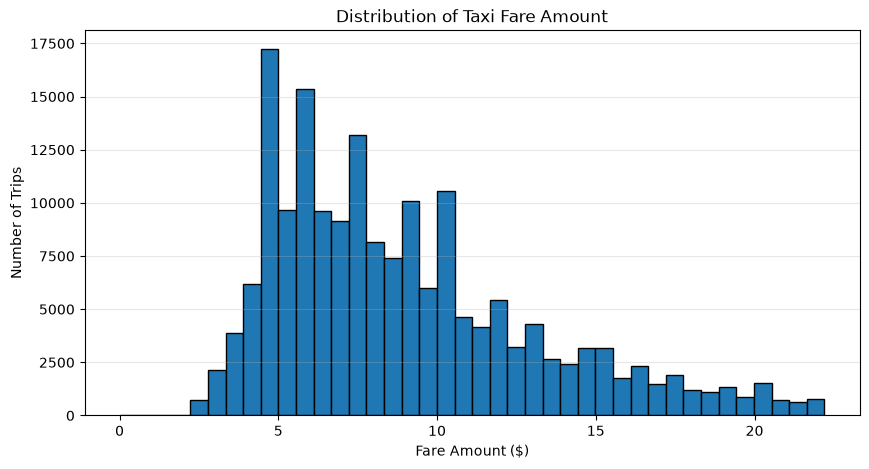

In [42]:

plt.figure(figsize=(10, 5))
plt.hist(data['fare_amount'], bins=40, edgecolor='black')
plt.title('Distribution of Taxi Fare Amount')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Number of Trips')
plt.grid(axis='y', alpha=0.3)
plt.show()

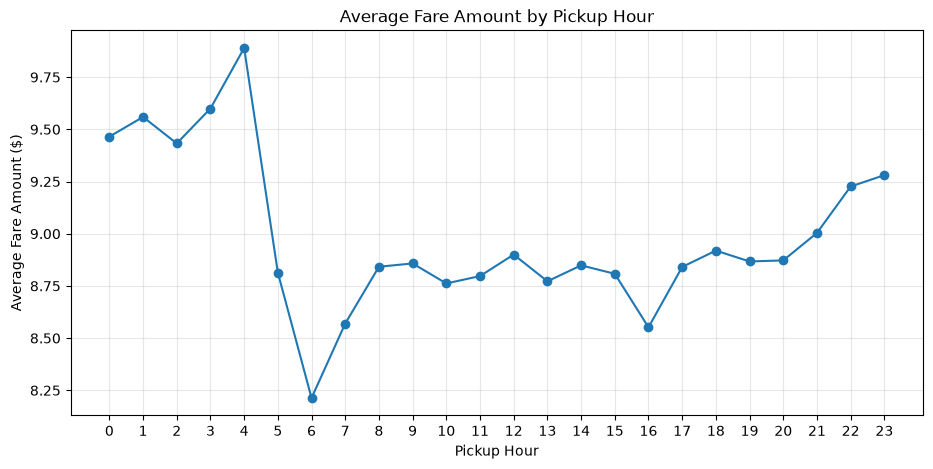

In [43]:

hourly_fare = data.groupby('pickup_hour')['fare_amount'].mean()

plt.figure(figsize=(11, 5))
plt.plot(hourly_fare.index, hourly_fare.values, marker='o')
plt.title('Average Fare Amount by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Fare Amount ($)')
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.show()

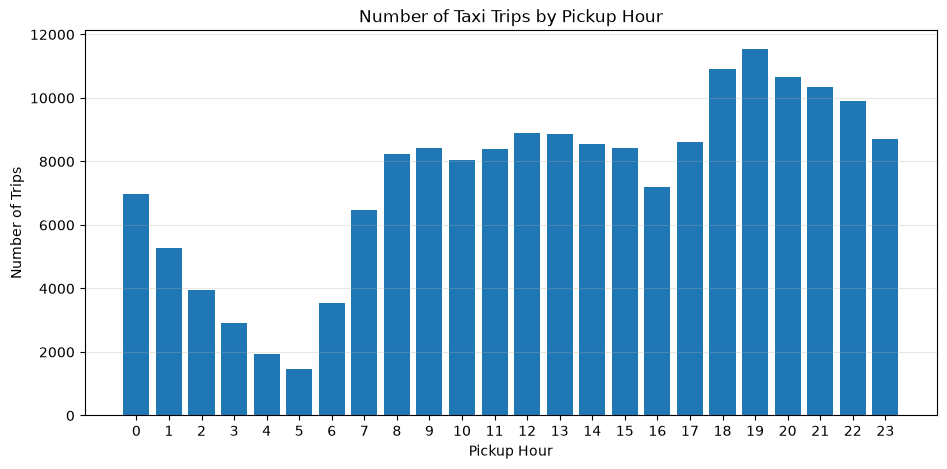

In [44]:

hourly_trips = data.groupby('pickup_hour').size()

plt.figure(figsize=(11, 5))
plt.bar(hourly_trips.index, hourly_trips.values)
plt.title('Number of Taxi Trips by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)
plt.show()

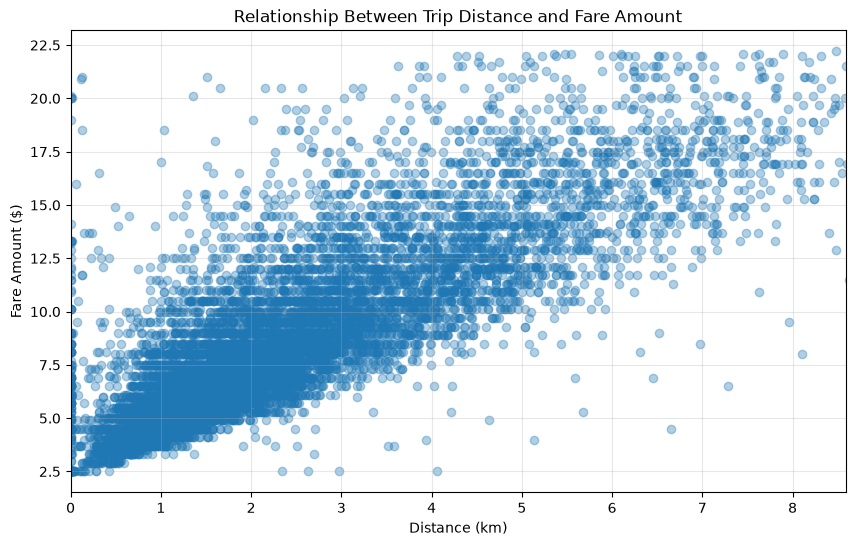

In [ ]:

sample_data = data.sample(n=min(10000, len(data)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(
    sample_data['distance_km'],
    sample_data['fare_amount'],
    alpha=0.35
)
plt.title('Relationship Between Trip Distance and Fare Amount')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.xlim(0, data['distance_km'].quantile(0.99))
plt.grid(alpha=0.3)
plt.show()

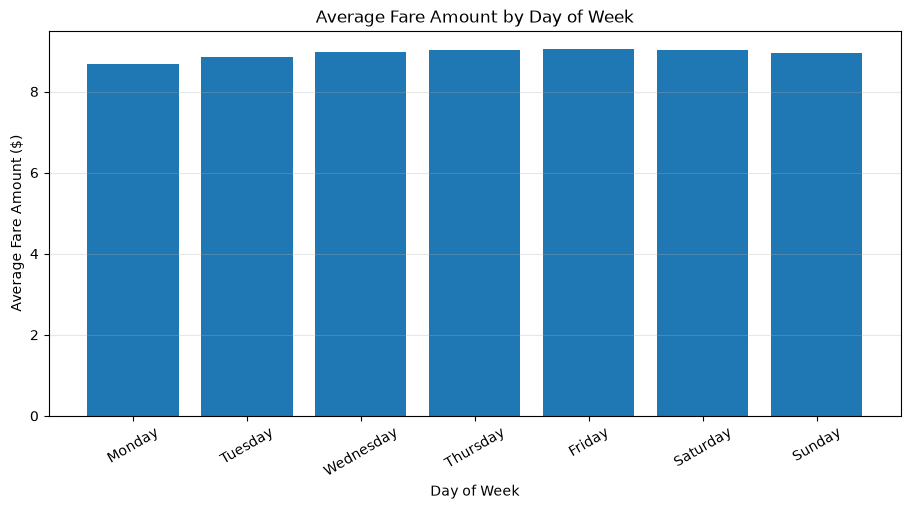

In [46]:

day_columns = [
    'day_Monday', 'day_Tuesday', 'day_Wednesday',
    'day_Thursday', 'day_Friday', 'day_Saturday', 'day_Sunday'
]

day_names = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

average_fare_by_day = []

for column in day_columns:
    average_fare = data.loc[data[column] == True, 'fare_amount'].mean()
    average_fare_by_day.append(average_fare)

plt.figure(figsize=(11, 5))
plt.bar(day_names, average_fare_by_day)
plt.title('Average Fare Amount by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Fare Amount ($)')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.show()

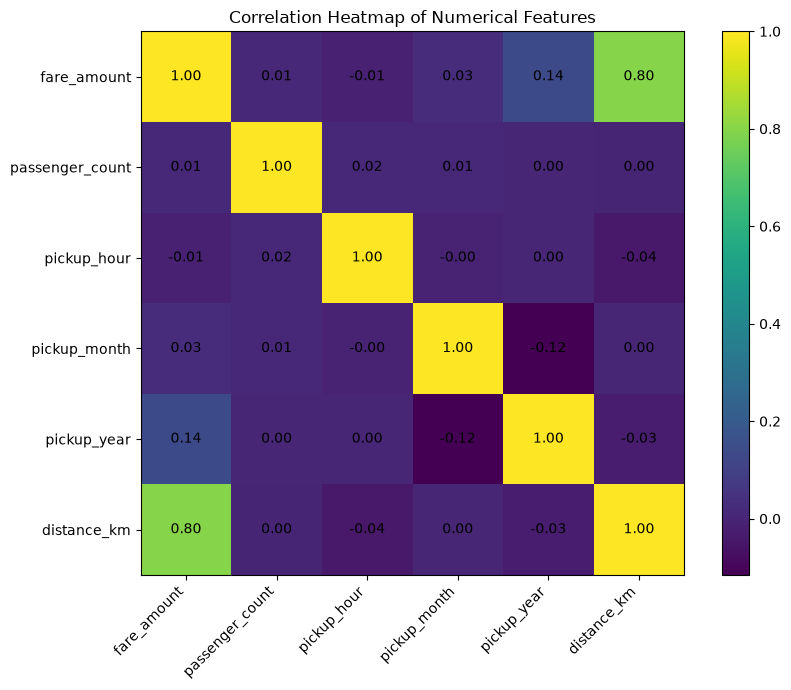

In [47]:

numeric_columns = [
    'fare_amount',
    'passenger_count',
    'pickup_hour',
    'pickup_month',
    'pickup_year',
    'distance_km'
]

correlation = data[numeric_columns].corr()

plt.figure(figsize=(9, 7))
plt.imshow(correlation, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation.columns)), correlation.columns)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i, f'{correlation.iloc[i, j]:.2f}', ha='center', va='center')

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [48]:
original_data = pd.read_csv(r"C:\Users\abdo\Downloads\Uber\uber.csv")


data['pickup_longitude'] = original_data['pickup_longitude']
data['pickup_latitude'] = original_data['pickup_latitude']
data['dropoff_longitude'] = original_data['dropoff_longitude']
data['dropoff_latitude'] = original_data['dropoff_latitude']


data.head()

,fare_amount,passenger_count,pickup_hour,pickup_month,pickup_year,distance_km,day_Friday,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,7.5,1,19,5,2015,1.683323,False,False,False,False,True,False,False,-73.999817,40.738354,-73.999512,40.723217
1,7.7,1,20,7,2009,2.457590,True,False,False,False,False,False,False,-73.994355,40.728225,-73.994710,40.750325
2,12.9,1,21,8,2009,5.036377,False,True,False,False,False,False,False,-74.005043,40.740770,-73.962565,40.772647
3,5.3,3,8,6,2009,1.661683,True,False,False,False,False,False,False,-73.976124,40.790844,-73.965316,40.803349
4,16.0,5,17,8,2014,4.475450,False,False,False,False,True,False,False,-73.925023,40.744085,-73.973082,40.761247


In [50]:
# قراءة الملف الأصلي
data = pd.read_csv(r"C:\Users\abdo\Downloads\Uber\uber.csv")

# حذف العمود التسلسلي إن وجد
data.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# تحويل التاريخ
data['pickup_datetime'] = pd.to_datetime(
    data['pickup_datetime'],
    errors='coerce',
    utc=True
)

# تنظيف القيم الأساسية
data = data.dropna()

data = data[
    (data['fare_amount'] > 0) &
    (data['passenger_count'].between(1, 6)) &
    (data['pickup_latitude'].between(40.4, 41.0)) &
    (data['dropoff_latitude'].between(40.4, 41.0)) &
    (data['pickup_longitude'].between(-74.3, -73.6)) &
    (data['dropoff_longitude'].between(-74.3, -73.6))
]

# حذف Outliers من fare_amount باستخدام IQR
Q1 = data['fare_amount'].quantile(0.25)
Q3 = data['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

data = data[
    (data['fare_amount'] >= Q1 - 1.5 * IQR) &
    (data['fare_amount'] <= Q3 + 1.5 * IQR)
]

# استخراج خصائص الوقت
data['pickup_hour'] = data['pickup_datetime'].dt.hour
data['pickup_day'] = data['pickup_datetime'].dt.day_name()
data['pickup_month'] = data['pickup_datetime'].dt.month
data['pickup_year'] = data['pickup_datetime'].dt.year

# تحويل اليوم إلى True / False
data = pd.get_dummies(
    data,
    columns=['pickup_day'],
    prefix='day',
    dtype=bool
)

# حساب المسافة
data['distance_km'] = haversine_distance(
    data['pickup_latitude'],
    data['pickup_longitude'],
    data['dropoff_latitude'],
    data['dropoff_longitude']
)

data.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_hour,pickup_month,pickup_year,day_Friday,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday,distance_km
0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,5,2015,False,False,False,False,True,False,False,1.683323
1,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,7,2009,True,False,False,False,False,False,False,2.457590
2,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,8,2009,False,True,False,False,False,False,False,5.036377
3,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,6,2009,True,False,False,False,False,False,False,1.661683
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,8,2014,False,False,False,False,True,False,False,4.475450


In [ ]:

data.drop(
    columns=['key', 'pickup_datetime'],
    inplace=True,
    errors='ignore'
)


data.columns

Index(['fare_amount', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_hour', 'pickup_month', 'pickup_year', 'day_Friday',
       'day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday',
       'day_Tuesday', 'day_Wednesday', 'distance_km'],
      dtype='str')